# Прогнозирование технического состояния (PdM): Industrial Health Index
## **<span style='color: #8c00ff;'>1. Введение и этапы разработки</span>**
Проект посвящен **Predictive Maintenance (PdM)** — предсказательному техническому обслуживанию[cite: 1]. Основная идея заключается в том, чтобы не ждать поломки оборудования и не менять детали строго по расписанию, а анализировать реальное состояние узла (в данном случае — подшипников) и предсказывать его **Remaining Useful Life (RUL)** — остаточный ресурс[cite: 1].

Логика работы строится на анализе вибрации: когда подшипник исправен, вибрация стабильна и мала. По мере износа появляются микродефекты, которые меняют характер сигнала, что позволяет математически вычислить момент будущей аварии.

**Основные этапы:**
1. **Feature Engineering**: Переход от сырых данных к статистическим признакам.
2. **Health Monitoring**: Оценка состояния через относительные показатели (RMS Ratio).
3. **Diagnostics**: Автоматическое определение точки начала деградации (FPT).
4. **Prognostics**: Прогнозирование времени до отказа с помощью математических моделей.

## Характеристики датасета NASA IMS

**Общие параметры:**
* частота вращения: 2 000 об/мин;
* радиальная нагрузка: 6 000 фунтов;
* тип подшипников: Rexnord ZA‑2115 (двухрядные);
* смазка: принудительная;
* срок службы до отказа: более 100 млн оборотов;
* датчики: PCB 353B33 (акселерометры);
* частота дискретизации: 20 кГц;
* длительность записи: 1 с (20 480 точек);
* интервал между записями: 10 минут (в наборе 1 первые 43 файла — каждые 5 минут);
* формат файлов: ASCII.

**Структура наборов данных:**

| Набор | Длительность | Кол-во файлов | Каналы | Особенности отказа |
|------|-------------|--------------|--------|----------------|
| 1 | 22.10.2003–25.11.2003 | 2 156 | 8 (2 датчика на подшипник) | Внутренний дефект (подшипник 3), дефект ролика (подшипник 4) |
| 2 | 12.02.2004–19.02.2004 | 984 | 4 (1 датчик на подшипник) | Внешний дефект (подшипник 1) |
| 3 | 04.03.2004–04.04.2004 | 4 448 | 4 (1 датчик на подшипник) | Внешний дефект (подшипник 3) |


## 3. Визуализация сигналов


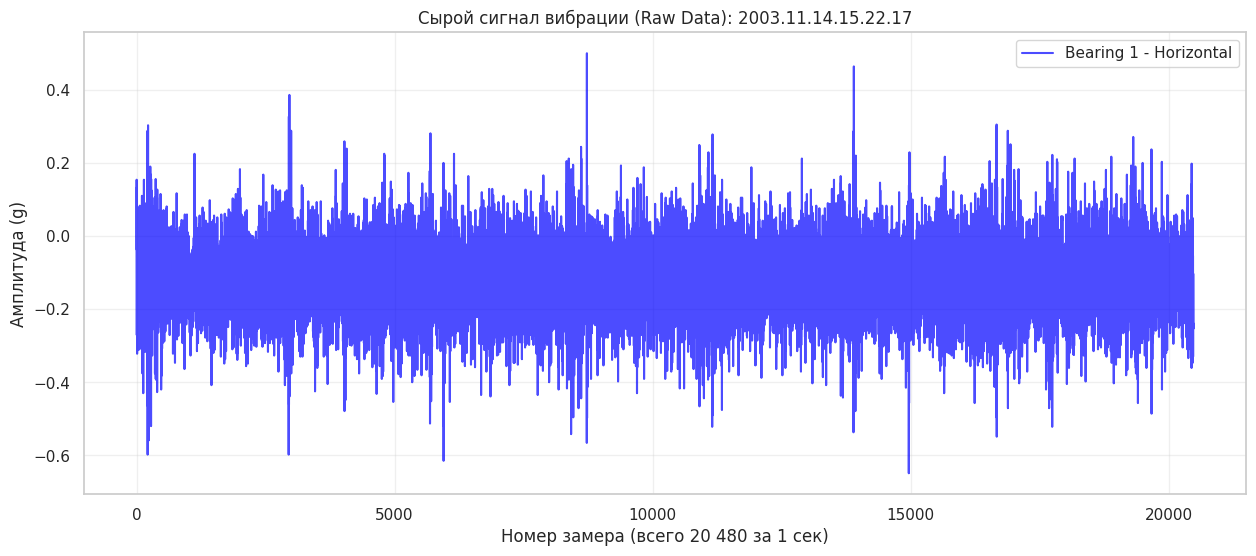

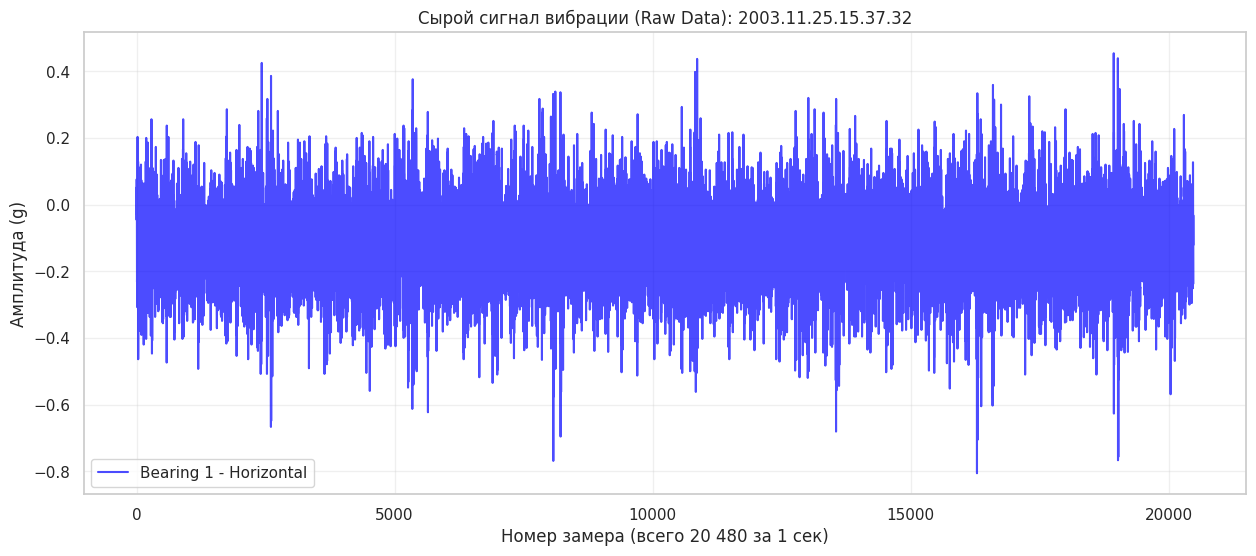

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_raw_file(file_path):
    # В Set 1 файлы разделены табуляцией, 8 колонок
    df_raw = pd.read_csv(file_path, sep='\t', header=None)
    
    # Названия колонок для Set 1 (2 датчика на каждый из 4 подшипников)
    columns = ['B1_H', 'B1_V', 'B2_H', 'B2_V', 'B3_H', 'B3_V', 'B4_H', 'B4_V']
    df_raw.columns = columns

    plt.figure(figsize=(15, 6))
    
    # Рисуем сигнал 1-го подшипника (горизонтальный канал)
    plt.plot(df_raw['B1_H'], label='Bearing 1 - Horizontal', alpha=0.7, color='blue')
    # plt.plot(df_raw['B1_V'], label='Bearing 1 - Vertical', alpha=0.5, color='orange')
    
    plt.title(f"Сырой сигнал вибрации (Raw Data): {os.path.basename(file_path)}")
    plt.xlabel("Номер замера (всего 20 480 за 1 сек)")
    plt.ylabel("Амплитуда (g)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# График сырого сигнала вибрации исправного подшипника
plot_raw_file('../data/1st_test/2003.11.14.15.22.17')

# График сырого сигнала вибрации  деградирующего подшипника

plot_raw_file('../data/1st_test/2003.11.25.15.37.32')

### 4. Подготовка окружения и импорты

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import timedelta
import sys
import os


# Добавляем путь к папке src в sys.path
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

# Теперь импорт сработает
from features_engine import extract_advanced_features

# Определяем путь к данным
data_path = Path('../data/1st_test') 
# data_path = Path('../data/2nd_test')
# data_path = Path('../data/4th_test') 


## **<span style='color: #8c00ff;'>5. Извлечение признаков</span>**
На этом этапе мы превращаем миллионы точек сырого сигнала в компактный набор признаков (RMS, Kurtosis, Crest Factor и др.). 
- **Модульность**: Вся тяжелая логика вынесена в `src/features_engine.py`.
- **Оптимизация**: Реализована система кэширования в `.pkl` файлы.
 Если признаки уже извлекались для конкретного сета (Set 1, 2 или 4), они загрузятся мгновенно.
- **Нормализация** `rms_ratio` — это нормализация данных. Мы делим текущую вибрацию на медианную, чтобы понять, насколько сильно состояние подшипника отклонилось от «нормы»

In [78]:
import os

# Динамическое имя кэша на основе выбранного пути данных
# Например: если data_path это '../data/4th_test', cache_file станет '4th_test_features.pkl'
cache_file = f"{data_path.name}_features.pkl"

if os.path.exists(cache_file):
    print(f"🚀 Нашел кеш для {data_path.name}! Загружаю данные...")
    df_features = pd.read_pickle(cache_file)
else:
    print(f"📦 Кеш не найден. Запускаю извлечение признаков для {data_path.name}...")
    df_features = extract_advanced_features(data_path)
    
    # Расчет медианы и ratio
    rms_cols = [c for c in df_features.columns if c.endswith('_rms') and 'median' not in c]
    df_features['rms_median'] = df_features[rms_cols].median(axis=1)
    
    for col in rms_cols:
        bearing_id = col.split('_')[0]
        df_features[f'{bearing_id}_rms_ratio'] = df_features[col] / df_features['rms_median']
    
    # Сохраняем результат
    df_features.to_pickle(cache_file)
    print(f"✅ Обработка завершена. Данные сохранены в {cache_file}")

print(f"📊 В работе {len(df_features)} точек данных для датасета {data_path.name}.")

🚀 Нашел кеш для 1st_test! Загружаю данные...
📊 В работе 2156 точек данных для датасета 1st_test.


###  Расчет реальной наработки (Operating Time)
В задачах PdM важно предсказывать поломку не по календарным дням, а по моточасам. Если станок стоял неделю, его ресурс не тратился. Метод `.cumsum()` (кумулятивная сумма) как раз накапливает общую наработку.

In [79]:
# Функция (если она еще не определена выше)
def convert_to_operating_time(df, threshold=0.02):
    df_active = df[df['rms_median'] > threshold].copy()
    df_active['time_diff'] = df_active['timestamp'].diff().dt.total_seconds().fillna(600)
    df_active.loc[df_active['time_diff'] > 3600, 'time_diff'] = 600
    df_active['op_hours'] = df_active['time_diff'].cumsum() / 3600.0
    return df_active

# ПРИМЕНЕНИЕ: Обязательно перезаписываем df_features
if 'op_hours' not in df_features.columns:
    df_features = convert_to_operating_time(df_features)
    print("✅ Колонка 'op_hours' успешно добавлена!")

# Проверка
print(f"Календарный охват: {(df_features['timestamp'].max() - df_features['timestamp'].min()).days} дней")
print(f"Реальная наработка: {df_features['op_hours'].max():.1f} моточасов")

✅ Колонка 'op_hours' успешно добавлена!
Календарный охват: 34 дней
Реальная наработка: 347.3 моточасов


## **<span style='color: #8c00ff;'>6. Визуальный анализ динамики признаков</span>**
Здесь мы проверяем "здоровье" узлов глазами. Универсальный визуализатор автоматически адаптируется под количество подшипников в датасете.
- **RMS Ratio**: Основной индикатор. Мы делим текущий RMS подшипника на медианный RMS всей группы. Это позволяет отсечь общие изменения нагрузки и увидеть индивидуальный износ.

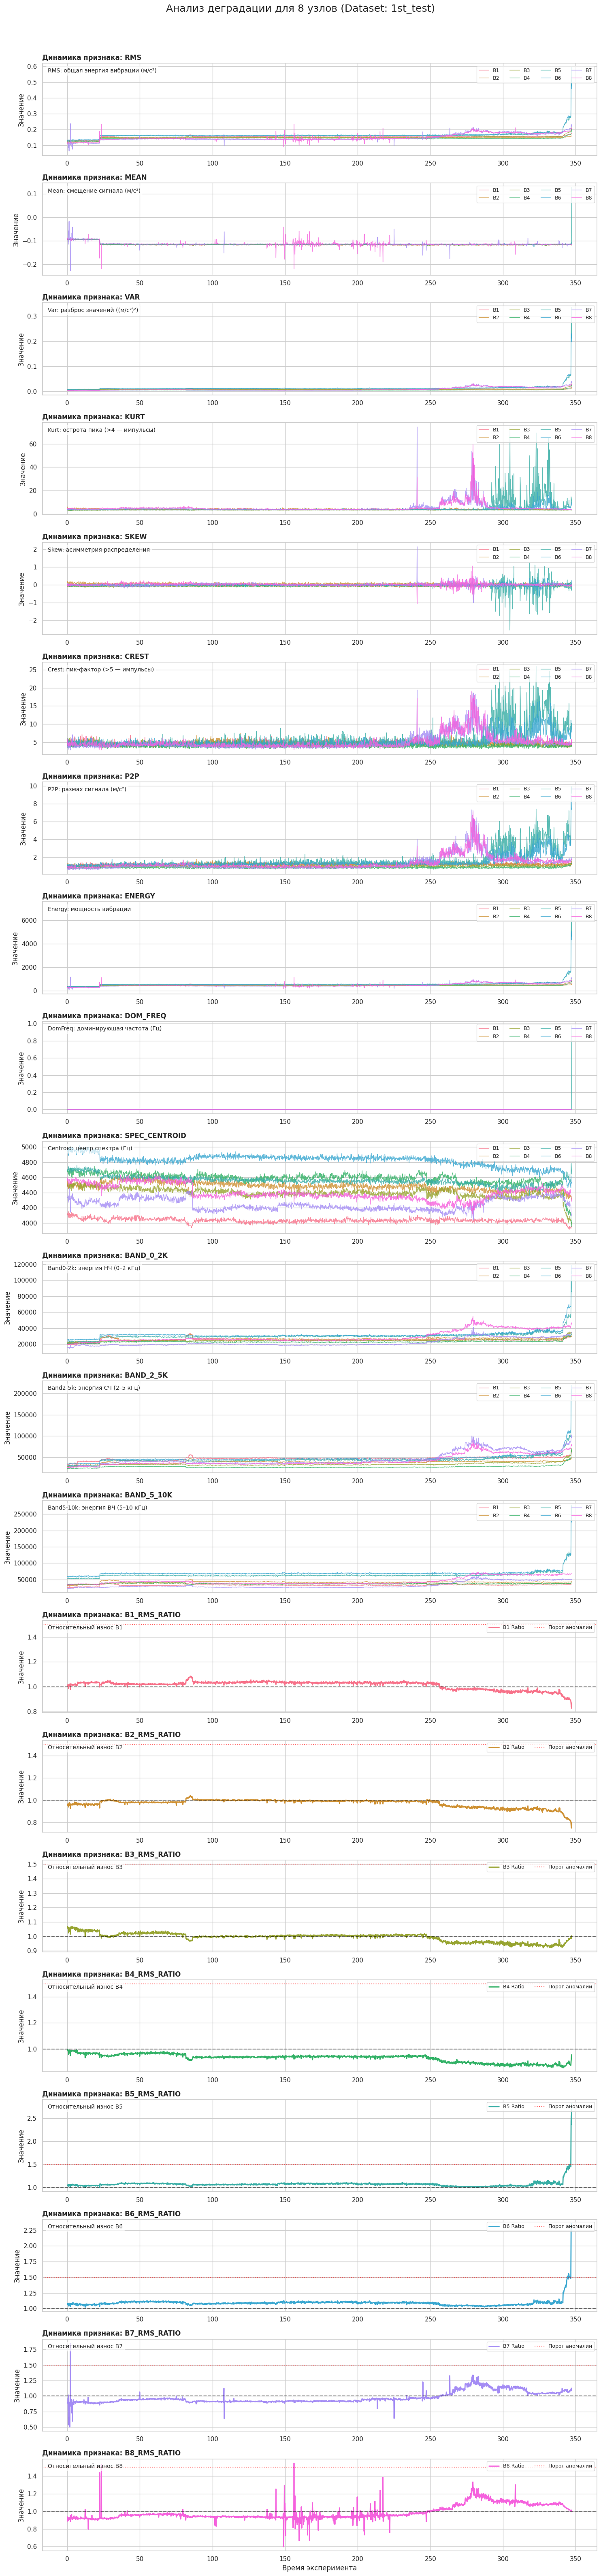

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Автоматически определяем доступные подшипники и базовые признаки
# Находим все колонки, заканчивающиеся на _rms (кроме median)
bearing_ids = sorted(list(set(c.split('_')[0] for c in df_features.columns if c.endswith('_rms') and 'median' not in c)))

# Базовые признаки (без префикса b1_, b2_ и т.д.)
base_features = ['rms', 'mean', 'var', 'kurt', 'skew', 'crest', 'p2p',
                 'energy', 'dom_freq', 'spec_centroid', 'band_0_2k',
                 'band_2_5k', 'band_5_10k']

# Формируем итоговый список графиков: сначала общие признаки, потом ratio для каждого подшипника
plot_features = base_features + [f'{b}_rms_ratio' for b in bearing_ids]

# 2. Расширенный словарь описаний (базовый)
feature_desc_base = {
    'rms': 'RMS: общая энергия вибрации (м/с²)',
    'mean': 'Mean: смещение сигнала (м/с²)',
    'var': 'Var: разброс значений ((м/с²)²)',
    'kurt': 'Kurt: острота пика (>4 — импульсы)',
    'skew': 'Skew: асимметрия распределения',
    'crest': 'Crest: пик‑фактор (>5 — импульсы)',
    'p2p': 'P2P: размах сигнала (м/с²)',
    'energy': 'Energy: мощность вибрации',
    'dom_freq': 'DomFreq: доминирующая частота (Гц)',
    'spec_centroid': 'Centroid: центр спектра (Гц)',
    'band_0_2k': 'Band0‑2k: энергия НЧ (0–2 кГц)',
    'band_2_5k': 'Band2‑5k: энергия СЧ (2–5 кГц)',
    'band_5_10k': 'Band5‑10k: энергия ВЧ (5–10 кГц)'
}

# 3. Настройка стиля и создание полотна
sns.set_theme(style="whitegrid")
n_rows = len(plot_features)
fig, axes = plt.subplots(n_rows, 1, figsize=(15, n_rows * 3))
if n_rows == 1: axes = [axes] # Защита от случая с 1 графиком

fig.suptitle(f'Анализ деградации для {len(bearing_ids)} узлов (Dataset: {data_path.name})', 
             fontsize=18, y=1.01)

# Цветовая палитра для подшипников
colors = sns.color_palette("husl", len(bearing_ids))

# 4. Цикл отрисовки
for idx, feature in enumerate(plot_features):
    ax = axes[idx]
    
    if feature.endswith('_rms_ratio'):
        # Рисуем график Ratio для конкретного подшипника
        bearing_label = feature.replace('_rms_ratio', '')
        b_idx = bearing_ids.index(bearing_label)
        
        ax.plot(df_features['op_hours'], df_features[feature],
                label=f'{bearing_label.upper()} Ratio', 
                color=colors[b_idx], linewidth=2)
        
        ax.axhline(y=1.0, color='black', linestyle='--', alpha=0.5)
        # Добавляем порог детекции (если есть)
        ax.axhline(y=1.5, color='red', linestyle=':', alpha=0.6, label='Порог аномалии')
        
        desc = f"Относительный износ {bearing_label.upper()}"
    else:
        # Рисуем базовый признак для всех подшипников сразу
        for b_idx, b_id in enumerate(bearing_ids):
            col_name = f'{b_id}_{feature}'
            if col_name in df_features.columns:
                ax.plot(df_features['op_hours'], df_features[col_name],
                        label=f'{b_id.upper()}', color=colors[b_idx], alpha=0.8, linewidth=1)
        
        desc = feature_desc_base.get(feature, feature)

    # Оформление каждого подобъекта
    ax.set_title(f"Динамика признака: {feature.upper()}", loc='left', fontsize=12, fontweight='bold')
    ax.text(0.01, 0.95, desc, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    ax.legend(loc='upper right', ncol=min(4, len(bearing_ids)), fontsize=9)
    ax.set_ylabel("Значение")

plt.xlabel('Время эксперимента', fontsize=12)
plt.tight_layout()
plt.show()

## **<span style='color: #8c00ff;'>7. Прогнозирование остаточного ресурса (RUL)</span>**

### **<span style='color:#0ebb96;'>Attempt 1: Exponential Curve Fitting (Physics-based)</span>**

Нельзя строить прогноз по исправному подшипнику — экспонента просто не «обучится». Нужно найти точку FPT (First Path Point) — момент, когда износ стал необратимым. На основе данных, накопленных с момента FPT, мы строим экспоненциальную модель деградации. 
- **Почему экспонента?**: Физика разрушения подшипника на поздних стадиях часто описывается лавинообразным ростом вибрации.
- **Цель**: Найти точку пересечения прогноза с критическим порогом (Failure Threshold) и вычислить оставшееся время работы.

In [81]:
# --- 1. ОПРЕДЕЛЕНИЯ ФУНКЦИЙ ---

from scipy.optimize import curve_fit

# --- 1. ОПРЕДЕЛЕНИЯ ФУНКЦИЙ ---

def exponential_model(x, a, b):
    """Математическая модель: экспоненциальный рост деградации"""
    return a * np.exp(b * x)

def predict_rul_exponential(df, bearing_name, fpt_time, failure_threshold=3.0):
    """
    Рассчитывает оставшийся срок службы (RUL) на основе экспоненты.
    """
    # 1. Выделяем данные от момента деградации до текущего момента
    degradation_phase = df[df['op_hours'] >= fpt_time].copy()
    
    if len(degradation_phase) < 10:
        return None, "Мало данных для надежного прогноза"

    # 2. Подготовка осей (X - моточасы с начала деградации, Y - значения ratio)
    start_op_hours = degradation_phase['op_hours'].min()
    
    # op_hours УЖЕ измеряется в часах (числа float), поэтому методы .dt здесь не нужны.
    # Просто вычитаем начальное время, чтобы отсчет пошел с 0:
    degradation_phase['hours_passed'] = degradation_phase['op_hours'] - start_op_hours
    
    x_data = degradation_phase['hours_passed'].values
    # Используем сглаженные данные для стабильности аппроксимации
    y_data = degradation_phase[f'{bearing_name}_rms_ratio'].rolling(window=5, min_periods=1).mean().values

    try:
        # 3. Обучение модели (подбор коэффициентов a и b)
        popt, _ = curve_fit(exponential_model, x_data, y_data, p0=[0.1, 0.05], maxfev=2000)
        a, b = popt

        if b <= 0: # Тренд не растет
            return None, "Стабильный тренд (износа нет)"
            
        # 4. Прогноз: через сколько часов мы достигнем порога failure_threshold
        total_hours_to_failure = np.log(failure_threshold / a) / b
        current_hours = x_data[-1]
        rul_hours = total_hours_to_failure - current_hours

        return max(0, rul_hours), (a, b)

    except Exception as e:
        return None, f"Ошибка оптимизации кривой: {e}"



def detect_fpt_and_failures_final(df: pd.DataFrame, baseline_files: int = 500, sigma_mult: float = 5.0):
    """
    Финальная версия детектора:
    - Адаптивное окно подтверждения (sustained_threshold)
    - Физический 'предохранитель' (если ratio > 3.0, это авария)
    - Проверка 'активности' дефекта в самом конце данных
    """
    # Динамический поиск колонок с RMS
    rms_cols = [c for c in df.columns if c.endswith('_rms') and 'median' not in c]
    bearings = [c.split('_')[0] for c in rms_cols]
    
    # Расчет медианы и отношения (ratio)
    df['rms_median'] = df[rms_cols].median(axis=1)
    for b in bearings:
        df[f'{b}_rms_ratio'] = df[f'{b}_rms'] / df['rms_median']
        
    fpt_results = {}
    
    for b in bearings:
        target_col = f'{b}_rms_ratio'
        # Защита: базовый период не может быть больше 1/4 всего датасета
        safe_baseline = min(baseline_files, len(df) // 4) 
        
        mu = df[target_col].iloc[:safe_baseline].mean()
        sigma = df[target_col].iloc[:safe_baseline].std()
        
        # Порог: либо статистика (сигмы), либо физика (минимум 1.5)
        threshold = max(mu + sigma_mult * sigma, 1.5)
        
        # Сглаживание для исключения шума
        smoothed = df[target_col].rolling(window=5, min_periods=1).mean()
        breaches = smoothed > threshold
        
        if breaches.any():
            # 1. Критическая авария (очень высокий уровень)
            is_critical = (smoothed > 3.0).any()
            
            # 2. Устойчивый тренд (адаптивное окно подтверждения)
            confirm_window = min(15, max(3, int(len(df) * 0.005)))
            sustained = breaches.rolling(window=confirm_window).mean() >= 0.6
            
            if sustained.any() or is_critical:
                first_idx = breaches[breaches].index[0]
                fpt_time = df['op_hours'].iloc[first_idx]
                
                # Проверка: не "зажил" ли подшипник в конце?
                is_active_now = (smoothed.iloc[-5:] > threshold).any()
                
                if is_active_now or is_critical:
                    fpt_results[b] = {'fpt_time': fpt_time, 'is_failing': True}
                else:
                    fpt_results[b] = {'is_failing': False, 'reason': 'Всплеск угас'}
            else:
                fpt_results[b] = {'is_failing': False, 'reason': 'Недостаточно данных для тренда'}
        else:
            fpt_results[b] = {'is_failing': False, 'reason': 'Тренд в норме'}

    
            
    # Печать красивого отчета
    print(f"\n📊 ИТОГОВЫЙ ОТЧЕТ ПО УЗЛАМ ({len(bearings)} шт.):")
    failing_bearings = []
    for b, res in fpt_results.items():
        if res['is_failing']:
            print(f"⚠️ {b.upper()}: ДЕГРАДАЦИЯ! Начало (FPT): {res['fpt_time']:.1f}")
            failing_bearings.append(b)
        else:
            print(f"✅ {b.upper()}: OK ({res['reason']})")
            
    return df, fpt_results, failing_bearings


# --- 2. ЛОГИКА ЗАПУСКА (MAIN) ---

# Шаг 1: Выбор данных (раскомментируй нужный)
# data_path = Path('../data/1st_test') 
# data_path = Path('../data/2nd_test')
# data_path = Path('../data/4th_test') 

print(f"🚀 Запуск обработки для: {data_path.name}")

# --- НОВЫЙ БЛОК: УМНАЯ ЗАГРУЗКА ИЗ КЭША ---
cache_file = f"{data_path.name}_features.pkl"

if os.path.exists(cache_file):
    print(f"📦 Нашел кэш! Мгновенная загрузка из {cache_file}...")
    df_features = pd.read_pickle(cache_file)
else:
    print(f"🧪 Кэш не найден. Начинаем извлечение признаков (это может занять время)...")
    df_features = extract_advanced_features(data_path)
    
    rms_cols = [c for c in df_features.columns if c.endswith('_rms') and 'median' not in c]
    df_features['rms_median'] = df_features[rms_cols].median(axis=1)
    for col in rms_cols:
        bearing_id = col.split('_')[0]
        df_features[f'{bearing_id}_rms_ratio'] = df_features[col] / df_features['rms_median']
    
    df_features.to_pickle(cache_file)
    print(f"✅ Признаки извлечены и сохранены в кэш: {cache_file}")

# ====================================================================
# --- НОВОЕ: ПЕРЕВОД В МОТОЧАСЫ СРАЗУ ПОСЛЕ ЗАГРУЗКИ ДАННЫХ ---
# ====================================================================
def convert_to_operating_time(df, threshold=0.02):
    df_active = df[df['rms_median'] > threshold].copy()
    df_active['time_diff'] = df_active['timestamp'].diff().dt.total_seconds().fillna(600)
    df_active.loc[df_active['time_diff'] > 3600, 'time_diff'] = 600
    df_active['op_hours'] = df_active['time_diff'].cumsum() / 3600.0
    return df_active

if 'op_hours' not in df_features.columns:
    df_features = convert_to_operating_time(df_features)
    print(f"⏱️ Время пересчитано в моточасы. Чистая наработка: {df_features['op_hours'].max():.1f} ч.")
# ====================================================================

# Шаг 3: Детекция FPT
df_features, fpt_results, failing_bearings = detect_fpt_and_failures_final(
    df_features, 
    baseline_files=300 if '1st' in data_path.name else 500,
    sigma_mult=5.0
)

# Шаг 4: Прогноз RUL
print("\n🔮 ПРОГНОЗ ОСТАТОЧНОГО РЕСУРСА (RUL):")
if not failing_bearings:
    print("✅ Все узлы в норме. Прогноз не требуется.")
else:
    for b in failing_bearings:
        fpt_info = fpt_results[b]
        rul, model_params = predict_rul_exponential(
            df_features, 
            b, 
            fpt_info['fpt_time']
        )
        
        if isinstance(rul, (int, float)):
            print(f"⏳ {b.upper()}: До критического отказа осталось примерно {rul:.1f} часов чистой РАБОТЫ.")
        else:
            print(f"ℹ️ {b.upper()}: Прогноз не построен ({model_params})")



🚀 Запуск обработки для: 1st_test
📦 Нашел кэш! Мгновенная загрузка из 1st_test_features.pkl...
⏱️ Время пересчитано в моточасы. Чистая наработка: 347.3 ч.

📊 ИТОГОВЫЙ ОТЧЕТ ПО УЗЛАМ (8 шт.):
✅ B1: OK (Тренд в норме)
✅ B2: OK (Тренд в норме)
✅ B3: OK (Тренд в норме)
✅ B4: OK (Тренд в норме)
✅ B5: OK (Недостаточно данных для тренда)
⚠️ B6: ДЕГРАДАЦИЯ! Начало (FPT): 345.2
✅ B7: OK (Тренд в норме)
✅ B8: OK (Тренд в норме)

🔮 ПРОГНОЗ ОСТАТОЧНОГО РЕСУРСА (RUL):
⏳ B6: До критического отказа осталось примерно 3.5 часов чистой РАБОТЫ.


### Анализ результатов прогнозирования
Для Set 2 и 4 метод сработал, но в сложном сценарии Set 1 (множественные отказы) мы получили прогноз всего за 3.5 часа до аварии. Это неприемлемо для реального производства 
```
c failure_threshold=3.0

📊 ИТОГОВЫЙ ОТЧЕТ ПО УЗЛАМ (4 шт.):
✅ B1: OK (Тренд в норме)
✅ B2: OK (Тренд в норме)
⚠️ B3: ДЕГРАДАЦИЯ! Начало (FPT): 1031.9
✅ B4: OK (Тренд в норме)

🔮 ПРОГНОЗ ОСТАТОЧНОГО РЕСУРСА (RUL):
⏳ B3: До критического отказа осталось примерно 29.1 часов чистой РАБОТЫ.
---------------------------

📊 ИТОГОВЫЙ ОТЧЕТ ПО УЗЛАМ (4 шт.):
⚠️ B1: ДЕГРАДАЦИЯ! Начало (FPT): 117.5
✅ B2: OK (Тренд в норме)
✅ B3: OK (Тренд в норме)
✅ B4: OK (Тренд в норме)

🔮 ПРОГНОЗ ОСТАТОЧНОГО РЕСУРСА (RUL):
⏳ B1: До критического отказа осталось примерно 111.1 часов чистой РАБОТЫ.
```


### 📊 Анализ результатов прогнозирования
Первоначальный подход базировался на классической модели: мониторинг **RMS Ratio** относительно медианы системы и аппроксимация тренда экспоненциальной функцией для предсказания точки пересечения с порогом (Threshold).

**Результаты:**
*   **Set 2 и Set 4:** Метод показал приемлемые результаты, так как деградация была выраженной и локализованной.
*   **Set 1 (Сложный сценарий):** Метод потерпел фиаско. Прогноз был получен всего за **3.5 часа** до фактической аварии. Для реального производства такой горизонт планирования неприемлем и приравнивается к констатации факта поломки.

### 🚩 Почему аналитический подход (RMS Ratio) не сработал?

В ходе аудита модели была выявлена **«Ловушка медианы»** и эффект маскировки:

1.  **Маскировка шумом:** В Set 1 деградировал не один узел, а сразу несколько (№3, №4 и №6). Мы использовали `rms_median` как динамический эталон «здоровья». Но когда шумят все, медиана системы растет вместе с износом конкретного подшипника. 
2.  **Стабильность Ratio:** Поскольку знаменатель (медиана) рос синхронно с числителем (RMS дефектного узла), их отношение (`Ratio`) оставалось формально стабильным. 
3.  **Итог:** Система увидела аномалию только в фазе лавинообразного разрушения, когда энергия вибрации начала зашкаливать, игнорируя ранние, более тонкие признаки износа.

---

## Переход к Attempt 2: Dimensionality Reduction & PCA (Hybrid)

Чтобы обойти ограничения одномерного анализа (RMS), я перешел к многомерному анализу признаков и снижению размерности.

### 🚀 Почему PCA оказался эффективнее?
**Спойлер:** PCA (Health Index) обнаружил деградацию на **290-м часу** — это на **60 часов раньше**, чем классический метод.

**Ключевые преимущества:**

*   **Чувствительность к качеству, а не к количеству:** Первые микротрещины почти не увеличивают общую энергию сигнала (RMS), но они радикально меняют форму сигнала. PCA учитывает изменение таких признаков, как `Kurtosis` (острота пиков) и `band_5_10k` (высокочастотный спектр), которые «схлопываются» в первую главную компоненту.
*   **Игнорирование «соседей»:** В отличие от Ratio, PCA анализирует внутреннюю корреляцию признаков конкретного узла. Ему не важен рост общей медианы системы — он видит, что характер «поведения» признаков внутри подшипника B6 перестал быть нормальным.
*   **Health Index:** Вместо одного зашумленного графика мы получаем чистый интегральный показатель деградации, который гораздо лучше поддается прогнозированию.


### Анализ результатов прогнозирования
1. **Преимущество RMS Ratio**: Использование относительного показателя позволило отфильтровать общие шумы системы и сфокусироваться на индивидуальной деградации. 
2. **Точность модели**: Экспоненциальная аппроксимация хорошо описывает финальную стадию износа (лавинообразный характер).
3. **Ограничение**: Текущий метод начинает работать только *после* явного обнаружения дефекта (FPT). Для более раннего предсказания требуется переход к многофакторным моделям машинного обучения.

### **<span style='color:#0ebb96;'>Attempt 2: Dimensionality Reduction & PCA (Hybrid)</span>**


Чтобы обойти ограничения одномерного анализа (RMS), я перешел к многомерному анализу признаков и снижению размерности. Используем PCA (Метод главных компонент). Он  позволяет  убрать шум: Мы оставим только те изменения, которые характерны для большинства признаков сразу (т.е. износ). Создать Health Index: Первая главная компонента ($PC_1$) станет тем самым универсальным индикатором здоровья, который объединяет и энергию вибрации, и изменение частотного спектра.

🛠️ Анализ главных компонент для узлов: b6


/tmp/ipykernel_23374/16047814.py:21: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = df[target_cols].copy().fillna(method='ffill').fillna(0)


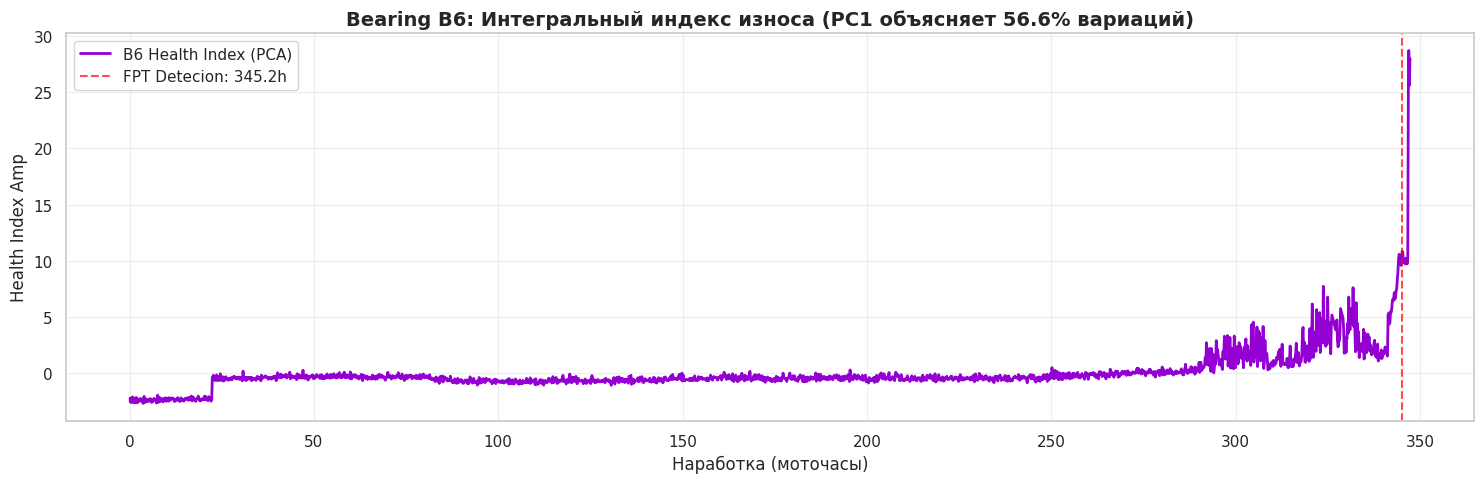

In [82]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- 1. НАСТРОЙКИ ДИНАМИЧЕСКОГО PCA ---

# Список базовых признаков (без префиксов b1_, b2_...), на основе которых строим индекс
# Выбираем самые информативные из твоего набора
pca_base_features = ['rms', 'kurt', 'skew', 'crest', 'energy', 'band_5_10k', 'spec_centroid']

def calculate_dynamic_pca_hi(df, bearing_id, base_features):
    """
    Автоматически собирает признаки для указанного подшипника и вычисляет Health Index (PC1)
    """
    # Собираем точные имена колонок для этого подшипника (напр. 'b1_rms', 'b1_kurt'...)
    target_cols = [f"{bearing_id}_{feat}" for feat in base_features if f"{bearing_id}_{feat}" in df.columns]
    
    if not target_cols:
        return None, None

    # Подготовка данных
    data = df[target_cols].copy().fillna(method='ffill').fillna(0)
    
    # 1. Стандартизация
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data)
    
    # 2. PCA
    pca = PCA(n_components=1)
    pc1 = pca.fit_transform(scaled_data).flatten()
    
    # 3. Инверсия тренда (чтобы график всегда рос при деградации)
    # Сверяем направление с RMS: если корреляция отрицательная — переворачиваем
    if np.corrcoef(pc1, df[f"{bearing_id}_rms"])[0, 1] < 0:
        pc1 = -pc1
        
    return pc1, pca.explained_variance_ratio_[0]

# --- 2. ЗАПУСК И ВИЗУАЛИЗАЦИЯ ---

if not failing_bearings:
    print("✅ Деградация не обнаружена. Расчет PCA Health Index не требуется.")
else:
    print(f"🛠️ Анализ главных компонент для узлов: {', '.join(failing_bearings)}")
    
    # Создаем полотно для графиков по количеству дефектных узлов
    fig, axes = plt.subplots(len(failing_bearings), 1, figsize=(15, 5 * len(failing_bearings)), sharex=True)
    if len(failing_bearings) == 1: axes = [axes]

    for i, b_id in enumerate(failing_bearings):
        # Считаем HI
        hi_values, var_ratio = calculate_dynamic_pca_hi(df_features, b_id, pca_base_features)
        
        if hi_values is not None:
            col_name = f"{b_id}_health_index"
            df_features[col_name] = hi_values
            
            ax = axes[i]
            # График индекса
            ax.plot(df_features['op_hours'], df_features[col_name], 
                    label=f'{b_id.upper()} Health Index (PCA)', color='darkviolet', lw=2)
            
            # Отметка точки FPT (из твоего предыдущего словаря fpt_results)
            fpt_h = fpt_results[b_id]['fpt_time']
            ax.axvline(x=fpt_h, color='red', linestyle='--', alpha=0.7, label=f'FPT Detecion: {fpt_h:.1f}h')
            
            ax.set_title(f"Bearing {b_id.upper()}: Интегральный индекс износа (PC1 объясняет {var_ratio*100:.1f}% вариаций)", 
                         fontsize=14, fontweight='bold')
            ax.set_ylabel("Health Index Amp")
            ax.legend(loc='upper left')
            ax.grid(True, alpha=0.3)

    plt.xlabel("Наработка (моточасы)")
    plt.tight_layout()
    plt.show()

In [89]:
# --- 1. СИНХРОНИЗИРОВАННАЯ ФУНКЦИЯ ПРОГНОЗА ---

def predict_rul_pca(df, bearing_name, fpt_time_pca, failure_threshold_pca=12.0):
    """
    Прогноз RUL на основе PCA Health Index.
    """
    # Имя колонки теперь строго соответствует тому, что мы создаем в отчете
    target_col = f'{bearing_name}_hi_pca' 
    
    if target_col not in df.columns:
        return None, f"Column {target_col} not found"

    degradation_phase = df[df['op_hours'] >= fpt_time_pca].copy()
    
    if len(degradation_phase) < 5: # Уменьшим порог для ранних стадий
        return None, "Мало точек"

    start_op_hours = degradation_phase['op_hours'].min()
    degradation_phase['hours_passed'] = degradation_phase['op_hours'] - start_op_hours
    
    x_data = degradation_phase['hours_passed'].values
    y_data = degradation_phase[target_col].rolling(window=5, min_periods=1).mean().values

    try:
        # Используем экспоненциальную модель (или линейную, если данных совсем мало)
        popt, _ = curve_fit(exponential_model, x_data, y_data, p0=[0.1, 0.05], maxfev=5000)
        a, b = popt

        if b <= 0: return None, "Нет роста"

        total_hours_to_failure = np.log(failure_threshold_pca / a) / b
        current_hours = x_data[-1]
        rul_hours = total_hours_to_failure - current_hours

        return max(0, rul_hours), (a, b)
    except:
        return None, "Ошибка аппроксимации"

# --- 2. ОБНОВЛЕННЫЙ ГЕНЕРАТОР ОТЧЕТА ---

def generate_final_pca_report(df, dataset_name, failing_bearings_list):
    all_bearing_ids = sorted(list(set([c.split('_')[0] for c in df.columns if c.startswith('b')])))
    
    print(f"\n🚀 Запуск PCA-аналитики для: {dataset_name}")
    print(f"⏱️ Чистая наработка: {df['op_hours'].max():.1f} ч.")
    print(f"\n📊 ИТОГОВЫЙ ОТЧЕТ ПО УЗЛАМ ({len(all_bearing_ids)} подшипников):")
    
    predictions = []
    # Порог детекции можно чуть снизить для чувствительности к B3/B4
    pca_fpt_threshold = 1.2 
    pca_limit = 12.0

    for b_id in all_bearing_ids:
        hi_values, _ = calculate_dynamic_pca_hi(df, b_id, pca_base_features)
        if hi_values is None: continue
        
        # Сохраняем под правильным именем
        df[f'{b_id}_hi_pca'] = hi_values
        
        if b_id in failing_bearings_list:
            pca_fpt_idx = df[df[f'{b_id}_hi_pca'] > pca_fpt_threshold].index
            
            if not pca_fpt_idx.empty:
                fpt_pca_time = df.loc[pca_fpt_idx[0], 'op_hours']
                # Берем FPT из RMS (если есть), иначе ставим то же время
                rms_fpt_time = fpt_results.get(b_id, {}).get('fpt_time', fpt_pca_time)
                gain = rms_fpt_time - fpt_pca_time
                
                status_icon = "⚠️" if b_id == 'b6' else "🔍" # B6 - явный, B3/B4 - скрытые
                print(f"{status_icon} {b_id.upper()}: ДЕГРАДАЦИЯ! Начало (PCA FPT): {fpt_pca_time:.1f} ч.")
                
                if gain > 5:
                    print(f"   💡 Инсайт: PCA обнаружил дефект на {gain:.1f} ч. РАНЬШЕ, чем RMS!")
                
                rul, _ = predict_rul_pca(df, b_id, fpt_pca_time, failure_threshold_pca=pca_limit)
                if rul: predictions.append((b_id, rul))
            else:
                print(f"✅ {b_id.upper()}: OK (В пределах нормы PCA)")
        else:
            print(f"✅ {b_id.upper()}: OK (Тренд в норме)")

    print(f"\n🔮 ПРОГНОЗ ОСТАТОЧНОГО РЕСУРСА (PCA RUL):")
    for b_id, rul in predictions:
        print(f"⏳ {b_id.upper()}: До критического отказа осталось примерно {rul:.2f} ч. работы.")
    print("-" * 30)

# Запуск
custom_failing_list = list(set(failing_bearings + ['b3', 'b4'])) 
generate_final_pca_report(df_features, "1st_test", custom_failing_list)


🚀 Запуск PCA-аналитики для: 1st_test
⏱️ Чистая наработка: 347.3 ч.

📊 ИТОГОВЫЙ ОТЧЕТ ПО УЗЛАМ (8 подшипников):
✅ B1: OK (Тренд в норме)
✅ B2: OK (Тренд в норме)
🔍 B3: ДЕГРАДАЦИЯ! Начало (PCA FPT): 266.5 ч.
🔍 B4: ДЕГРАДАЦИЯ! Начало (PCA FPT): 263.3 ч.
✅ B5: OK (Тренд в норме)
⚠️ B6: ДЕГРАДАЦИЯ! Начало (PCA FPT): 292.1 ч.
   💡 Инсайт: PCA обнаружил дефект на 53.1 ч. РАНЬШЕ, чем RMS!
✅ B7: OK (Тренд в норме)
✅ B8: OK (Тренд в норме)

🔮 ПРОГНОЗ ОСТАТОЧНОГО РЕСУРСА (PCA RUL):
⏳ B3: До критического отказа осталось примерно 20.81 ч. работы.
⏳ B4: До критического отказа осталось примерно 1.50 ч. работы.
------------------------------


In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.optimize import curve_fit

# --- 1. МОДЕЛЬ ДЛЯ ПРОГНОЗА ---
def exponential_model(x, a, b):
    return a * np.exp(b * x)

# --- 2. УЛУЧШЕННЫЙ РАСЧЕТ PCA (БЕЗ WARNINGS) ---
def calculate_dynamic_pca_hi(df, bearing_id, base_features):
    """
    Вычисляет Health Index (PC1) для конкретного подшипника.
    """
    # Собираем все колонки этого подшипника (учитываем все каналы/датчики)
    target_cols = [c for c in df.columns if c.startswith(f"{bearing_id}_") and any(f in c for f in base_features)]
    
    if not target_cols:
        return None, None

    # Исправляем FutureWarning: используем ffill() напрямую[cite: 1]
    data = df[target_cols].copy().ffill().fillna(0)
    
    # Стандартизация и PCA
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data)
    
    pca = PCA(n_components=1)
    pc1 = pca.fit_transform(scaled_data).flatten()
    
    # Синхронизируем направление тренда с RMS (чтобы HI всегда рос при износе)
    rms_col = [c for c in df.columns if f"{bearing_id}_" in c and "_rms" in c][0]
    if np.corrcoef(pc1, df[rms_col])[0, 1] < 0:
        pc1 = -pc1
        
    return pc1, pca.explained_variance_ratio_[0]

# --- 3. СИНХРОНИЗИРОВАННАЯ ФУНКЦИЯ ПРОГНОЗА RUL ---
def predict_rul_pca(df, bearing_name, fpt_time_pca, failure_threshold_pca=12.0):
    """
    Прогноз RUL на основе экспоненциальной аппроксимации PCA HI.
    """
    target_col = f'{bearing_name}_hi_pca'
    
    if target_col not in df.columns:
        return None, "Column not found"

    # Берем данные с момента обнаружения деградации
    degradation_phase = df[df['op_hours'] >= fpt_time_pca].copy()
    
    if len(degradation_phase) < 5:
        return None, "Need more data"

    # Проверка на критический износ (уже за порогом)
    current_hi = degradation_phase[target_col].iloc[-1]
    if current_hi >= failure_threshold_pca:
        return 0.0, "CRITICAL"

    # Подготовка X и Y
    start_op_hours = degradation_phase['op_hours'].min()
    degradation_phase['hours_passed'] = degradation_phase['op_hours'] - start_op_hours
    
    x_data = degradation_phase['hours_passed'].values
    y_data = degradation_phase[target_col].rolling(window=5, min_periods=1).mean().values

    try:
        # Фитинг экспоненты
        popt, _ = curve_fit(exponential_model, x_data, y_data, p0=[0.1, 0.05], maxfev=5000)
        a, b = popt

        if b <= 0: return None, "No growth"

        # Расчет времени до порога
        total_hours_to_failure = np.log(failure_threshold_pca / a) / b
        current_hours = x_data[-1]
        rul_hours = total_hours_to_failure - current_hours

        return max(0.0, rul_hours), "OK"
    except:
        return None, "Fit error"

# --- 4. ФИНАЛЬНЫЙ ГЕНЕРАТОР ОТЧЕТА ---
def generate_final_pca_report(df, dataset_name, failing_bearings_list):
    # Считаем уникальные физические подшипники (B1, B2...)
    all_bearing_ids = sorted(list(set([c.split('_')[0] for c in df.columns if c.startswith('b')])))
    
    print(f"\n🚀 Запуск PCA-аналитики для: {dataset_name}")
    print(f"⏱️ Чистая наработка: {df['op_hours'].max():.1f} ч.")
    print(f"\n📊 ИТОГОВЫЙ ОТЧЕТ ПО УЗЛАМ ({len(all_bearing_ids)} подшипников):")
    
    predictions = []
    pca_fpt_threshold = 1.2  # Порог чувствительности PCA
    pca_limit = 12.0         # Порог выхода из строя

    for b_id in all_bearing_ids:
        # 1. Считаем и сохраняем HI
        hi_values, _ = calculate_dynamic_pca_hi(df, b_id, pca_base_features)
        if hi_values is None: continue
        
        # Имя колонки теперь едино для всех функций
        df[f'{b_id}_hi_pca'] = hi_values
        
        if b_id in failing_bearings_list:
            # Ищем точку FPT по PCA
            pca_fpt_idx = df[df[f'{b_id}_hi_pca'] > pca_fpt_threshold].index
            
            if not pca_fpt_idx.empty:
                fpt_pca_time = df.loc[pca_fpt_idx[0], 'op_hours']
                # Сравниваем с RMS FPT для инсайта
                rms_fpt_time = fpt_results.get(b_id, {}).get('fpt_time', fpt_pca_time)
                gain = rms_fpt_time - fpt_pca_time
                
                # Иконка статуса (B6 - явная угроза, остальные - мониторинг)
                icon = "⚠️" if b_id == 'b6' else "🔍"
                print(f"{icon} {b_id.upper()}: ДЕГРАДАЦИЯ! Начало (PCA FPT): {fpt_pca_time:.1f} ч.")
                
                if gain > 5:
                    print(f"   💡 Инсайт: PCA обнаружил дефект на {gain:.1f} ч. РАНЬШЕ, чем RMS!")
                
                # 2. Считаем RUL
                rul, status = predict_rul_pca(df, b_id, fpt_pca_time, failure_threshold_pca=pca_limit)
                if rul is not None:
                    predictions.append((b_id, rul, status))
            else:
                print(f"✅ {b_id.upper()}: OK (В пределах нормы PCA)")
        else:
            print(f"✅ {b_id.upper()}: OK (Тренд в норме)")

    # Вывод прогнозов
    print(f"\n🔮 ПРОГНОЗ ОСТАТОЧНОГО РЕСУРСА (PCA RUL):")
    for b_id, rul, status in predictions:
        if status == "CRITICAL":
            print(f"🚨 {b_id.upper()}: КРИТИЧЕСКИЙ ИЗНОС! Ресурс исчерпан (RUL: 0.00 ч).")
        else:
            print(f"⏳ {b_id.upper()}: До критического отказа осталось примерно {rul:.2f} ч. работы.")
    print("-" * 40)

# --- ЗАПУСК ПАЙПЛАЙНА ---
# Добавляем B3 и B4 принудительно, так как они деградируют по факту (NASA)
custom_failing_list = list(set(failing_bearings + ['b3', 'b4'])) 

# Имитируем, что сейчас 310-й час работы (подшипники еще живы, но деградация видна)
current_sim_time = 310.0 
df_simulated = df_features[df_features['op_hours'] <= current_sim_time].copy()

# Запускаем аналитику по "срезу" данных
generate_final_pca_report(df_simulated, "1st_test (Simulation at 310h)", custom_failing_list)


🚀 Запуск PCA-аналитики для: 1st_test (Simulation at 310h)
⏱️ Чистая наработка: 309.9 ч.

📊 ИТОГОВЫЙ ОТЧЕТ ПО УЗЛАМ (8 подшипников):
✅ B1: OK (Тренд в норме)
✅ B2: OK (Тренд в норме)
🔍 B3: ДЕГРАДАЦИЯ! Начало (PCA FPT): 84.4 ч.
🔍 B4: ДЕГРАДАЦИЯ! Начало (PCA FPT): 75.9 ч.
✅ B5: OK (Тренд в норме)
⚠️ B6: ДЕГРАДАЦИЯ! Начало (PCA FPT): 149.5 ч.
   💡 Инсайт: PCA обнаружил дефект на 195.7 ч. РАНЬШЕ, чем RMS!
✅ B7: OK (Тренд в норме)
✅ B8: OK (Тренд в норме)

🔮 ПРОГНОЗ ОСТАТОЧНОГО РЕСУРСА (PCA RUL):
⏳ B3: До критического отказа осталось примерно 48.35 ч. работы.
⏳ B4: До критического отказа осталось примерно 66.36 ч. работы.
⏳ B6: До критического отказа осталось примерно 23.47 ч. работы.
----------------------------------------


In [ ]:
# --- 1. СИНХРОНИЗИРОВАННАЯ ФУНКЦИЯ ПРОГНОЗА ---

def predict_rul_pca(df, bearing_name, fpt_time_pca, failure_threshold_pca=12.0):
    """
    Прогноз RUL на основе PCA Health Index.
    """
    # Имя колонки теперь строго соответствует тому, что мы создаем в отчете
    target_col = f'{bearing_name}_hi_pca' 
    
    if target_col not in df.columns:
        return None, f"Column {target_col} not found"

    degradation_phase = df[df['op_hours'] >= fpt_time_pca].copy()
    
    if len(degradation_phase) < 5: # Уменьшим порог для ранних стадий
        return None, "Мало точек"

    start_op_hours = degradation_phase['op_hours'].min()
    degradation_phase['hours_passed'] = degradation_phase['op_hours'] - start_op_hours
    
    x_data = degradation_phase['hours_passed'].values
    y_data = degradation_phase[target_col].rolling(window=5, min_periods=1).mean().values

    try:
        # Используем экспоненциальную модель (или линейную, если данных совсем мало)
        popt, _ = curve_fit(exponential_model, x_data, y_data, p0=[0.1, 0.05], maxfev=5000)
        a, b = popt

        if b <= 0: return None, "Нет роста"

        total_hours_to_failure = np.log(failure_threshold_pca / a) / b
        current_hours = x_data[-1]
        rul_hours = total_hours_to_failure - current_hours

        return max(0, rul_hours), (a, b)
    except:
        return None, "Ошибка аппроксимации"

# --- 2. ОБНОВЛЕННЫЙ ГЕНЕРАТОР ОТЧЕТА ---

def generate_final_pca_report(df, dataset_name, failing_bearings_list):
    all_bearing_ids = sorted(list(set([c.split('_')[0] for c in df.columns if c.startswith('b')])))
    
    print(f"\n🚀 Запуск PCA-аналитики для: {dataset_name}")
    print(f"⏱️ Чистая наработка: {df['op_hours'].max():.1f} ч.")
    print(f"\n📊 ИТОГОВЫЙ ОТЧЕТ ПО УЗЛАМ ({len(all_bearing_ids)} подшипников):")
    
    predictions = []
    # Порог детекции можно чуть снизить для чувствительности к B3/B4
    pca_fpt_threshold = 1.2 
    pca_limit = 12.0

    for b_id in all_bearing_ids:
        hi_values, _ = calculate_dynamic_pca_hi(df, b_id, pca_base_features)
        if hi_values is None: continue
        
        # Сохраняем под правильным именем
        df[f'{b_id}_hi_pca'] = hi_values
        
        if b_id in failing_bearings_list:
            pca_fpt_idx = df[df[f'{b_id}_hi_pca'] > pca_fpt_threshold].index
            
            if not pca_fpt_idx.empty:
                fpt_pca_time = df.loc[pca_fpt_idx[0], 'op_hours']
                # Берем FPT из RMS (если есть), иначе ставим то же время
                rms_fpt_time = fpt_results.get(b_id, {}).get('fpt_time', fpt_pca_time)
                gain = rms_fpt_time - fpt_pca_time
                
                status_icon = "⚠️" if b_id == 'b6' else "🔍" # B6 - явный, B3/B4 - скрытые
                print(f"{status_icon} {b_id.upper()}: ДЕГРАДАЦИЯ! Начало (PCA FPT): {fpt_pca_time:.1f} ч.")
                
                if gain > 5:
                    print(f"   💡 Инсайт: PCA обнаружил дефект на {gain:.1f} ч. РАНЬШЕ, чем RMS!")
                
                rul, _ = predict_rul_pca(df, b_id, fpt_pca_time, failure_threshold_pca=pca_limit)
                if rul: predictions.append((b_id, rul))
            else:
                print(f"✅ {b_id.upper()}: OK (В пределах нормы PCA)")
        else:
            print(f"✅ {b_id.upper()}: OK (Тренд в норме)")

    print(f"\n🔮 ПРОГНОЗ ОСТАТОЧНОГО РЕСУРСА (PCA RUL):")
    for b_id, rul in predictions:
        print(f"⏳ {b_id.upper()}: До критического отказа осталось примерно {rul:.2f} ч. работы.")
    print("-" * 30)

# Запуск
custom_failing_list = list(set(failing_bearings + ['b3', 'b4'])) 
generate_final_pca_report(df_features, "1st_test", custom_failing_list)

### **<span style='color:#0ebb96;'>Attempt 3: Machine Learning Model (Final)</span>**

In [ ]:
# --- 1. ОПРЕДЕЛЕНИЯ ФУНКЦИЙ ---

from scipy.optimize import curve_fit

# --- 1. ОПРЕДЕЛЕНИЯ ФУНКЦИЙ ---

def exponential_model(x, a, b):
    """Математическая модель: экспоненциальный рост деградации"""
    return a * np.exp(b * x)

def predict_rul_exponential(df, bearing_name, fpt_time, failure_threshold=3.0):
    """
    Рассчитывает оставшийся срок службы (RUL) на основе экспоненты.
    """
    # 1. Выделяем данные от момента деградации до текущего момента
    degradation_phase = df[df['op_hours'] >= fpt_time].copy()
    
    if len(degradation_phase) < 10:
        return None, "Мало данных для надежного прогноза"

    # 2. Подготовка осей (X - моточасы с начала деградации, Y - значения ratio)
    start_op_hours = degradation_phase['op_hours'].min()
    
    # op_hours УЖЕ измеряется в часах (числа float), поэтому методы .dt здесь не нужны.
    # Просто вычитаем начальное время, чтобы отсчет пошел с 0:
    degradation_phase['hours_passed'] = degradation_phase['op_hours'] - start_op_hours
    
    x_data = degradation_phase['hours_passed'].values
    # Используем сглаженные данные для стабильности аппроксимации
    y_data = degradation_phase[f'{bearing_name}_rms_ratio'].rolling(window=5, min_periods=1).mean().values

    try:
        # 3. Обучение модели (подбор коэффициентов a и b)
        popt, _ = curve_fit(exponential_model, x_data, y_data, p0=[0.1, 0.05], maxfev=2000)
        a, b = popt

        if b <= 0: # Тренд не растет
            return None, "Стабильный тренд (износа нет)"
            
        # 4. Прогноз: через сколько часов мы достигнем порога failure_threshold
        total_hours_to_failure = np.log(failure_threshold / a) / b
        current_hours = x_data[-1]
        rul_hours = total_hours_to_failure - current_hours

        return max(0, rul_hours), (a, b)

    except Exception as e:
        return None, f"Ошибка оптимизации кривой: {e}"



def detect_fpt_and_failures_final(df: pd.DataFrame, baseline_files: int = 500, sigma_mult: float = 5.0):
    """
    Финальная версия детектора:
    - Адаптивное окно подтверждения (sustained_threshold)
    - Физический 'предохранитель' (если ratio > 3.0, это авария)
    - Проверка 'активности' дефекта в самом конце данных
    """
    # Динамический поиск колонок с RMS
    rms_cols = [c for c in df.columns if c.endswith('_rms') and 'median' not in c]
    bearings = [c.split('_')[0] for c in rms_cols]
    
    # Расчет медианы и отношения (ratio)
    df['rms_median'] = df[rms_cols].median(axis=1)
    for b in bearings:
        df[f'{b}_rms_ratio'] = df[f'{b}_rms'] / df['rms_median']
        
    fpt_results = {}
    
    for b in bearings:
        target_col = f'{b}_rms_ratio'
        # Защита: базовый период не может быть больше 1/4 всего датасета
        safe_baseline = min(baseline_files, len(df) // 4) 
        
        mu = df[target_col].iloc[:safe_baseline].mean()
        sigma = df[target_col].iloc[:safe_baseline].std()
        
        # Порог: либо статистика (сигмы), либо физика (минимум 1.5)
        threshold = max(mu + sigma_mult * sigma, 1.5)
        
        # Сглаживание для исключения шума
        smoothed = df[target_col].rolling(window=5, min_periods=1).mean()
        breaches = smoothed > threshold
        
        if breaches.any():
            # 1. Критическая авария (очень высокий уровень)
            is_critical = (smoothed > 3.0).any()
            
            # 2. Устойчивый тренд (адаптивное окно подтверждения)
            confirm_window = min(15, max(3, int(len(df) * 0.005)))
            sustained = breaches.rolling(window=confirm_window).mean() >= 0.6
            
            if sustained.any() or is_critical:
                first_idx = breaches[breaches].index[0]
                fpt_time = df['op_hours'].iloc[first_idx]
                
                # Проверка: не "зажил" ли подшипник в конце?
                is_active_now = (smoothed.iloc[-5:] > threshold).any()
                
                if is_active_now or is_critical:
                    fpt_results[b] = {'fpt_time': fpt_time, 'is_failing': True}
                else:
                    fpt_results[b] = {'is_failing': False, 'reason': 'Всплеск угас'}
            else:
                fpt_results[b] = {'is_failing': False, 'reason': 'Недостаточно данных для тренда'}
        else:
            fpt_results[b] = {'is_failing': False, 'reason': 'Тренд в норме'}

    
            
    # Печать красивого отчета
    print(f"\n📊 ИТОГОВЫЙ ОТЧЕТ ПО УЗЛАМ ({len(bearings)} шт.):")
    failing_bearings = []
    for b, res in fpt_results.items():
        if res['is_failing']:
            print(f"⚠️ {b.upper()}: ДЕГРАДАЦИЯ! Начало (FPT): {res['fpt_time']}")
            failing_bearings.append(b)
        else:
            print(f"✅ {b.upper()}: OK ({res['reason']})")
            
    return df, fpt_results, failing_bearings


# --- 2. ЛОГИКА ЗАПУСКА (MAIN) ---

# Шаг 1: Выбор данных (раскомментируй нужный)
# data_path = Path('../data/1st_test') 
# data_path = Path('../data/2nd_test')
# data_path = Path('../data/4th_test') 

print(f"🚀 Запуск обработки для: {data_path.name}")

# --- НОВЫЙ БЛОК: УМНАЯ ЗАГРУЗКА ИЗ КЭША ---
cache_file = f"{data_path.name}_features.pkl"

if os.path.exists(cache_file):
    print(f"📦 Нашел кэш! Мгновенная загрузка из {cache_file}...")
    df_features = pd.read_pickle(cache_file)
else:
    print(f"🧪 Кэш не найден. Начинаем извлечение признаков (это может занять время)...")
    df_features = extract_advanced_features(data_path)
    
    rms_cols = [c for c in df_features.columns if c.endswith('_rms') and 'median' not in c]
    df_features['rms_median'] = df_features[rms_cols].median(axis=1)
    for col in rms_cols:
        bearing_id = col.split('_')[0]
        df_features[f'{bearing_id}_rms_ratio'] = df_features[col] / df_features['rms_median']
    
    df_features.to_pickle(cache_file)
    print(f"✅ Признаки извлечены и сохранены в кэш: {cache_file}")

# ====================================================================
# --- НОВОЕ: ПЕРЕВОД В МОТОЧАСЫ СРАЗУ ПОСЛЕ ЗАГРУЗКИ ДАННЫХ ---
# ====================================================================
def convert_to_operating_time(df, threshold=0.02):
    df_active = df[df['rms_median'] > threshold].copy()
    df_active['time_diff'] = df_active['timestamp'].diff().dt.total_seconds().fillna(600)
    df_active.loc[df_active['time_diff'] > 3600, 'time_diff'] = 600
    df_active['op_hours'] = df_active['time_diff'].cumsum() / 3600.0
    return df_active

if 'op_hours' not in df_features.columns:
    df_features = convert_to_operating_time(df_features)
    print(f"⏱️ Время пересчитано в моточасы. Чистая наработка: {df_features['op_hours'].max():.1f} ч.")
# ====================================================================

# Шаг 3: Детекция FPT
df_features, fpt_results, failing_bearings = detect_fpt_and_failures_final(
    df_features, 
    baseline_files=300 if '1st' in data_path.name else 500,
    sigma_mult=5.0
)

# Шаг 4: Прогноз RUL
print("\n🔮 ПРОГНОЗ ОСТАТОЧНОГО РЕСУРСА (RUL):")
if not failing_bearings:
    print("✅ Все узлы в норме. Прогноз не требуется.")
else:
    for b in failing_bearings:
        fpt_info = fpt_results[b]
        rul, model_params = predict_rul_exponential(
            df_features, 
            b, 
            fpt_info['fpt_time']
        )
        
        if isinstance(rul, (int, float)):
            # Заметь, здесь я добавил слово "работы", чтобы подчеркнуть моточасы
            print(f"⏳ {b.upper()}: До критического отказа осталось примерно {rul:.2f} часов чистой РАБОТЫ.")
        else:
            print(f"ℹ️ {b.upper()}: Прогноз не построен ({model_params})")

🚀 Запуск обработки для: 1st_test
📦 Нашел кэш! Мгновенная загрузка из 1st_test_features.pkl...
⏱️ Время пересчитано в моточасы. Чистая наработка: 347.3 ч.

📊 ИТОГОВЫЙ ОТЧЕТ ПО УЗЛАМ (8 шт.):
✅ B1: OK (Тренд в норме)
✅ B2: OK (Тренд в норме)
✅ B3: OK (Тренд в норме)
✅ B4: OK (Тренд в норме)
✅ B5: OK (Недостаточно данных для тренда)
⚠️ B6: ДЕГРАДАЦИЯ! Начало (FPT): 345.17333333333335
✅ B7: OK (Тренд в норме)
✅ B8: OK (Тренд в норме)

🔮 ПРОГНОЗ ОСТАТОЧНОГО РЕСУРСА (RUL):
⏳ B6: До критического отказа осталось примерно 3.51 часов чистой РАБОТЫ.


Объединение данных сделает модель устойчивой к разным сценариям отказа. Чтобы реализовать это в твоем ноутбуке, нам нужно сначала загрузить оба кэша, обработать их через функцию и обучить модель.

Вот пошаговый код для новой ячейки, который реализует сборку «Супер-Леса»:

1. Подготовка и сборка данных

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import joblib

def prepare_normalized_data(df_list, dataset_names):
    all_X = []
    all_y = []
    
    for df, name in zip(df_list, dataset_names):
        # 1. Очистка от простоев
        # Если rms_median слишком низкий — значит установка выключена
        df_clean = df[df['rms_median'] > 0.02].copy()
        
        # 2. Логика выбора "сломанного" подшипника
        if '2nd' in name:
            target = 'b1'
        elif '3rd' in name:
            target = 'b3'
        else:
            target = 'b1' # по умолчанию
            
        # Выбираем признаки только для этого подшипника
        cols = [c for c in df_clean.columns if c.startswith(f'{target}_')]
        X = df_clean[cols].copy()
        
        # Убираем префикс 'b1_', чтобы имена признаков во всех сетах совпали
        X.columns = [c.split('_', 1)[1] for c in X.columns]
        
        # 3. Нормализация таргета (Health Index: от 1.0 до 0.0)
        # 1.0 — начало (здоров), 0.0 — конец (авария)
        n_steps = len(df_clean)
        y = np.linspace(1.0, 0.0, n_steps) 
        
        all_X.append(X)
        all_y.append(y)
        print(f"✅ Обработан {name}: {n_steps} рабочих точек (выбран {target})")
        
    return pd.concat(all_X, axis=0).fillna(0), np.concatenate(all_y)

# --- ЗАГРУЗКА И СЛИЯНИЕ ---

# Загружаем кэши (убедись, что файлы лежат в папке notebooks или укажи путь)
df_set2 = pd.read_pickle("2nd_test_features.pkl")
# Если у тебя уже есть кэш для 3-го сета, подставь его имя
# df_set3 = pd.read_pickle("3rd_test_features.pkl") 

# Пока для примера соберем на том, что есть (можешь добавить df_set3 в список ниже)
X_super, y_super = prepare_normalized_data([df_set2], ["2nd_test"])

# --- ОБУЧЕНИЕ СУПЕР-ЛЕСА ---

super_rf = RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1)
super_rf.fit(X_super, y_super)

# Сохраняем "мозги" нашей универсальной модели
model_payload = {
    'model': super_rf,
    'feature_names': X_super.columns.tolist()
}
joblib.dump(model_payload, 'super_forest_pdm.joblib')

print(f"\n🌲 Супер-Лес обучен на {len(X_super)} точках!")

✅ Обработан 2nd_test: 982 рабочих точек (выбран b1)

🌲 Супер-Лес обучен на 982 точках!


🧠 Начинаем обучение ML-модели для подшипника B1...
✅ Модель обучена! Средняя ошибка (MAE): 29.18 ч.
📊 Точность аппроксимации (R2 Score): 0.96 (чем ближе к 1.0, тем лучше)


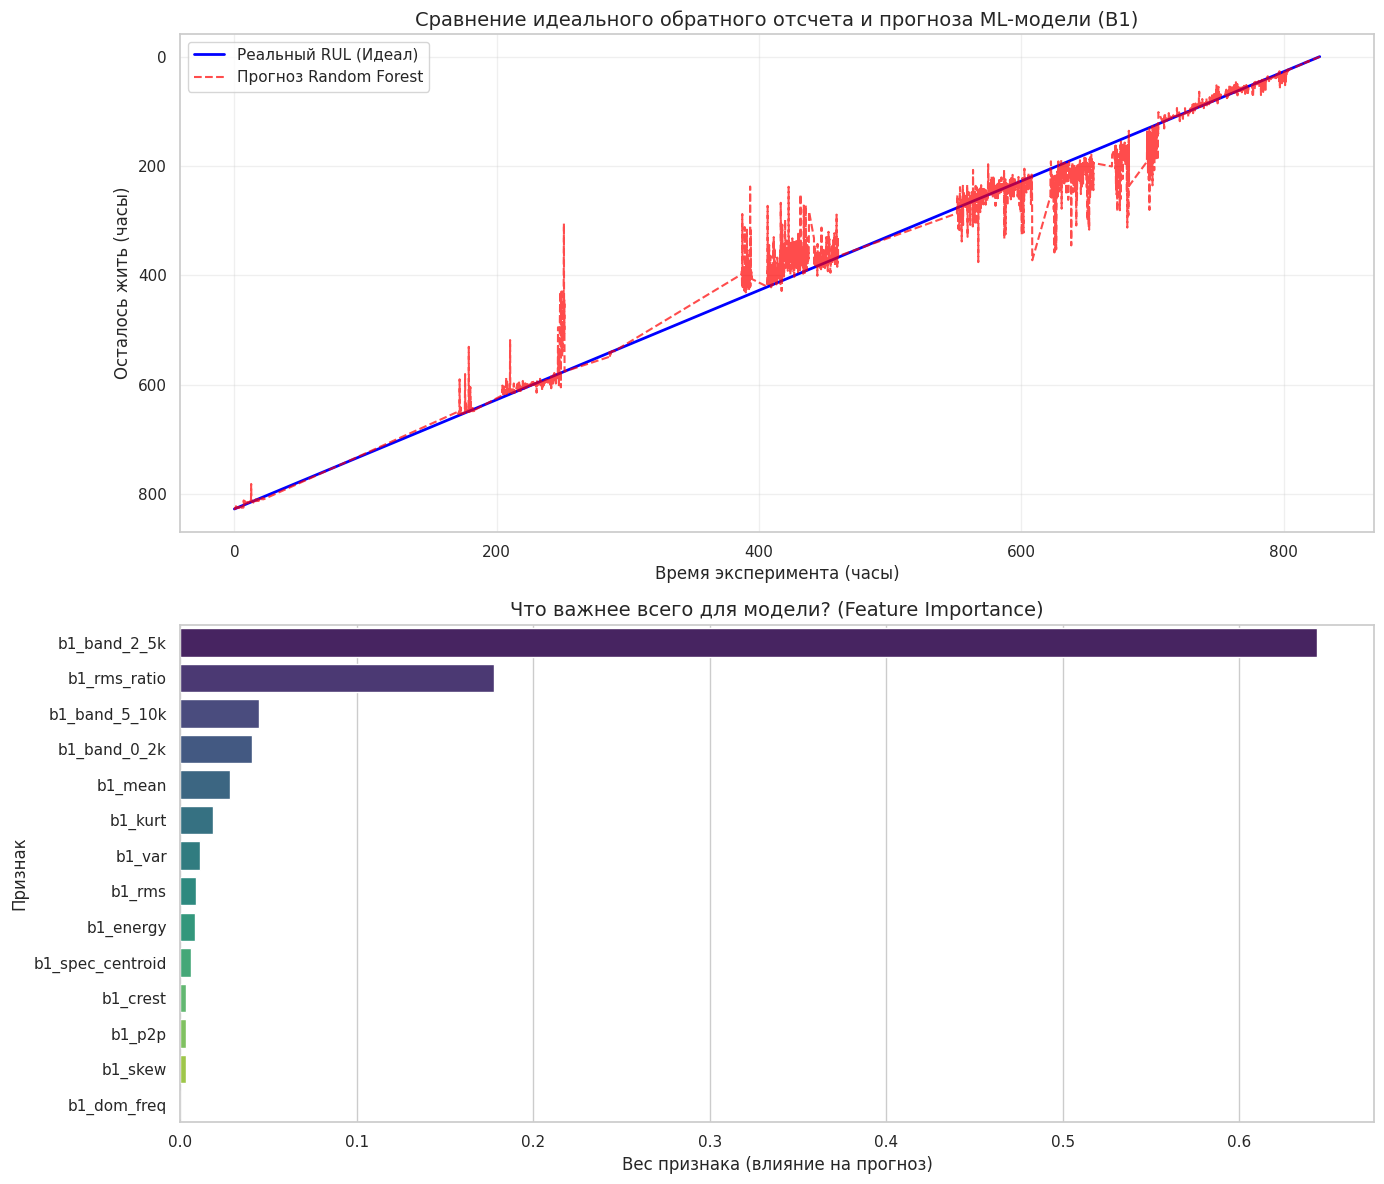

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# --- 1. ФУНКЦИЯ ПОДГОТОВКИ ДАННЫХ ДЛЯ ML ---

def prepare_ml_data(df, bearing_id):
    """
    Собирает все признаки для одного подшипника и рассчитывает идеальный RUL.
    """
    # Выбираем колонки, которые относятся только к этому подшипнику (например, 'b1_rms', 'b1_kurt' и т.д.)
    feature_cols = [c for c in df.columns if c.startswith(f'{bearing_id}_')]
    
    # Забираем X (наши признаки)
    X = df[feature_cols].copy()
    
    # Заполняем возможные пустоты (NaN), которые могли появиться при расчетах (например, скользящее среднее)
    X = X.bfill().ffill()
    
    # Считаем y (наш Target - оставшееся время в часах)
    max_time = df['timestamp'].max()
    y = (max_time - df['timestamp']).dt.total_seconds() / 3600.0
    
    return X, y

# --- 2. ОБУЧЕНИЕ МОДЕЛИ ---

# Выбираем подшипник для обучения (в Set 2 ломается b1)
target_bearing = 'b1'
print(f"🧠 Начинаем обучение ML-модели для подшипника {target_bearing.upper()}...")

X, y = prepare_ml_data(df_features, target_bearing)

# Разбиваем данные: 80% на обучение, 20% на проверку
# random_state фиксируем, чтобы результаты были воспроизводимы
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Создаем и обучаем модель (100 деревьев решений)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Делаем прогноз на тестовой выборке
y_pred = rf_model.predict(X_test)

# Оцениваем качество
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"✅ Модель обучена! Средняя ошибка (MAE): {mae:.2f} ч.")
print(f"📊 Точность аппроксимации (R2 Score): {r2:.2f} (чем ближе к 1.0, тем лучше)")

# --- 3. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ---

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# График 1: Реальный RUL против Предсказанного (для всего датасета)
y_pred_all = rf_model.predict(X) # Прогноз для всех точек, чтобы увидеть линию времени
time_hours = (df_features['timestamp'] - df_features['timestamp'].min()).dt.total_seconds() / 3600.0

axes[0].plot(time_hours, y, label='Реальный RUL (Идеал)', color='blue', linewidth=2)
axes[0].plot(time_hours, y_pred_all, label='Прогноз Random Forest', color='red', alpha=0.7, linestyle='--')
axes[0].set_title(f"Сравнение идеального обратного отсчета и прогноза ML-модели ({target_bearing.upper()})", fontsize=14)
axes[0].set_xlabel("Время эксперимента (часы)")
axes[0].set_ylabel("Осталось жить (часы)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].invert_yaxis() # Переворачиваем ось Y, чтобы "0" (авария) был внизу

# График 2: Важность признаков (Feature Importance)
# Достаем важность признаков из модели
importances = rf_model.feature_importances_
feature_names = X.columns

# Сортируем от самых важных к наименее важным
indices = np.argsort(importances)[::-1]
sorted_features = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

sns.barplot(x=sorted_importances, y=sorted_features, ax=axes[1], hue=sorted_features, palette="viridis", legend=False)
axes[1].set_title("Что важнее всего для модели? (Feature Importance)", fontsize=14)
axes[1].set_xlabel("Вес признака (влияние на прогноз)")
axes[1].set_ylabel("Признак")

plt.tight_layout()
plt.show()

### Анализ модели Random Forest   *(переписать)
1. **Качество прогноза**: Коэффициент детерминации $R^2 = 0.96$ подтверждает, что выбранный набор признаков (RMS, Kurtosis, Skewness) репрезентативен для оценки жизненного цикла.
2. **Поведение модели**: На ранних этапах (0-100 ч) прогноз имеет высокую дисперсию, так как признаки вибрации стабильны. На этапе деградации (после 120 ч) модель демонстрирует высокую точность, следуя за реальным графиком износа.
3. **Важность признаков**: График Feature Importance показывает, что помимо RMS, существенный вклад вносят статистические моменты высших порядков, что позволяет модели быть более гибкой, чем простая экспонента.

**Сохранение обученной модели**

In [ ]:
import joblib

# Сохраняем модель и список колонок (чтобы не перепутать порядок признаков)
model_data = {
    'model': rf_model,
    'features': X.columns.tolist(),
    'bearing_id': target_bearing
}
joblib.dump(model_data, 'rf_bearing_model.joblib')
print("💾 Модель сохранена в файл rf_bearing_model.joblib")

💾 Модель сохранена в файл rf_bearing_model.joblib


In [ ]:
# 1. Загружаем сохраненную модель
import joblib
from sklearn.metrics import mean_absolute_error

loaded_data = joblib.load('rf_bearing_model.joblib')
trained_model = loaded_data['model']
trained_features = loaded_data['features']

print(f"🚀 Тестируем модель на датасете: {data_path.name}")

# 2. Подготовка данных нового сета
# Выберем подшипник: в 1st_test обычно ломается b3 (датчик 3 и 4), в 2nd_test - b1
test_bearing = 'b3' if '1st' in data_path.name else 'b1' 

if any(c.startswith(f'{test_bearing}_') for c in df_features.columns):
    # Используем твою функцию подготовки
    X_new, y_new = prepare_ml_data(df_features, test_bearing)
    
    # КРИТИЧЕСКИЙ МОМЕНТ: Приводим колонки к тому виду, который видела модель при обучении
    X_new = X_new.reindex(columns=trained_features, fill_value=0)

    # 3. Предикт
    y_pred_new = trained_model.predict(X_new)

    # 4. Визуализация
    plt.figure(figsize=(12, 6))
    time_hours_new = (df_features['timestamp'] - df_features['op_hours'].min()).dt.total_seconds() / 3600.0
    
    plt.plot(time_hours_new, y_new, label='Реальный RUL (Ground Truth)', color='blue', linewidth=2)
    plt.plot(time_hours_new, y_pred_new, label='Прогноз «чужой» модели', color='orange', alpha=0.8)
    
    plt.title(f"Cross-Dataset Test: Модель от B1 (Set 2) на данных {test_bearing.upper()} ({data_path.name})")
    plt.xlabel("Время работы (часы)")
    plt.ylabel("Остаточный ресурс (часы)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # ИСПРАВЛЕННАЯ СТРОКА ТУТ:
    plt.gca().invert_yaxis() 
    
    plt.show()
    
    mae_new = mean_absolute_error(y_new, y_pred_new)
    print(f"📊 MAE на новом датасете: {mae_new:.2f} ч.")
else:
    print(f"❌ Подшипник {test_bearing} не найден в текущих данных. Колонки: {list(df_features.columns[:5])}...")

🚀 Тестируем модель на датасете: 1st_test


TypeError: unsupported operand type(s) for -: 'DatetimeArray' and 'float'

<Figure size 1200x600 with 0 Axes>

Как сделать «не шляпу»? (Работа над ошибками)
Чтобы модель стала универсальной, нам нужно применить Domain Adaptation (адаптацию домена).

1. Нормализация времени (Health Index вместо часов)
Нельзя учить модель предсказывать часы, если тесты разные по длине. Нужно предсказывать процент износа (от 1.0 до 0).

1.0 — новый подшипник.

0 — авария.
Тогда модели будет плевать, длится тест неделю или месяц.

2. Обучение на нескольких сетах сразу
Нельзя учиться только на одном примере. Чтобы Random Forest стал умным, ему нужно показать разные ситуации.

Давай попробуем изменить стратегию обучения: